# Predicting NBA Defensive Player of the Year: A Data Driven Approach (2014 - 2024)

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Andy Nguyen
- Tim Mao
- Shawn Malal
- Luca Schenck
- An-Chi Lu

# Abstract

The NBA's Defensive Player of the Year (DPOY) Award is one of the most highly-touted honors an individual player can receive, however, the selection process is meticulous, obscure, and even secretive. This project utilizes machine learning to predict the winner of the NBA's DPOY Award by exploring the most indicative defensive metrics over the last ten years. Paired wiht Exploratory Data Analysis on how DPOYs of the past stack up against their competition, we trained a Support Vector Machine (SVM), a Logistic Regression Model, and a Decision Tree Classifier to analyze key defensive measures, such as steals, blocks, defensive win shares, and many more that players have throughout a given NBA season. Our models were trained on NBA player data from the 2013-2014 season up until the 2022-2023 season, and then tested on the 2023 season, which then generated a ranked list of likely DPOY candidates. Results indicate that defensive win shares and block percentage were among the strongest predictors, which highlights the importance of individual contributions to team defense. Our models successfully identified top contenders, aligning with real-world voting trends. This project demonstrates the power and potential of data-driven analytics in award predictions while suggesting further refinements, such as incorporating advanced tracking data and positional impact metrics, to improve predictive accuracy.

# Research Question

Can we predict the NBA Defensive Player of the Year (DPOY) winner and nominees using historical data of players' height and weight along with stats such as defensive rebounds, steals, blocks, and team standing from the 2014-2024 NBA regular seasons?

# Background and Prior Work

## Introduction

Our topic for this project is related to the NBA award of DPOY (Defensive Player of the Year) which is given to a single individual player at the end of the NBA season. Multiple people can be nominated for this, though once again, only a single individual can win the actual award. The goal of this project is to see if we can build a model that uses an NBA player's stats, height/wingspan, and their team's overall season record with their defensive rating, to to determine whether they are eligible to be nominated for the award. Here: (https://www.espn.com/nba/history/awards/_/id/39) ESPN has a list of all the past winning DPOY players with some of their stats (although could be biased due to player voting).

## Prior Work

In the recent years with the rise of machine learning and statistical models analysts and reporters have started utilizing technology to leverage insights and predictions about various aspects of the NBA. One popular metric that is often up to predictions is the MVP (another accolade that is awareded at the same time/method as our studied metric; DPOY). With one quick google search we can find multiple websites where various people have tried to use data science to predict the MVP. 

In the first [example](https://nba-mvp-predictor.streamlit.app/)[1], Paul[2] uses statistical regression along with data science practices to get his MVP predictions. From his Github page there are different files which show how he trains his model, preprocesses the data, how he scrapes the data, how the predictions are done and evaluated, and much more. Through inspiration from his code we can develop and tweak our own code to train and process data in order to find the DPOY rather than the MVP. However, his code is only working to predict the current candidates for the 2024-2025 NBA season, we want to be able to apply our code to every season current and past.

Another example comes from Bruin Sports Analytics [3]. They performed Exploratory Data Analysis (EDA) and created their own machine learning model to predict the DPOY for the current NBA season. Their study considers and trains their model using data starting from 1983, when the award was first introduced. They take into account many variables such as Defensive Win Shares, Defensive Plus-Minus, and other defensive factors. However, they do not address our research question regarding the role of physical attributes in predicting the DPOY. Additionally, their study focuses on comparing the previous winner of the award, a player people believed should have won, and the stats of past DPOY winners—making it more of an analysis of the 2023-2024 DPOY race rather than a broad predictive model. However, their inclusion of team defensive performance and overall rating is relevant to our study.

While both of these projects present strong data science approaches, neither fully addresses our key research question: Can we predict the DPOY winner using specific attributes such as height, wingspan, and other stats? The first reference employs regression models and current-season data to predict the MVP, which we could adapt to instead predict the DPOY for both current and past seasons. The second reference takes an EDA approach to analyzing DPOY outcomes but focuses on comparing specific players rather than examining the entire player pool, which is the objective of our project. Therefore, in this project, we aim to determine which factors influence a player's chances of winning Defensive Player of the Year in the NBA.

## References
1. https://nba-mvp-predictor.streamlit.app/
2. https://github.com/pauldes/nba-mvp-predictor
3. https://www.bruinsportsanalytics.com/post/2024-nba-dpoy


# Hypothesis


- Null hypothesis: There is no relationship between a player's height, weight, blocks, steals, rebounds, team standing, and their likelihood of winning the Defensive Player of the Year (DPOY) award or being nominated as a possible winner.

- Alternative hypothesis: There is a relationship between a player's height, weight, blocks, steals, rebounds, team standing, and their likelihood of winning the Defensive Player of the Year (DPOY) award or being nominated as a possible winner.

We hypothesize that a predictive model can accurately identify the NBA Defensive Player of the Year (DPOY) winner and nominees using historical data from the 2014-2024 regular seasons. Prior research suggests that defensive metrics such as steals, blocks, and defensive rebounds are strong indicators of defensive impact and recognition in award voting (e.g., Goldsberry, 2019). Additionally, player physical attributes like wingspan, height, and weight have been linked to defensive effectiveness, particularly in shot-blocking and on-ball defense (Schwarz & Huston, 2015). Given these established correlations, we expect that integrating these features, alongside team success, will yield a robust classification model capable of predicting DPOY selections with high accuracy.

# Data & Data Cleaning

## Ideal Dataset

Our ideal dataset would be stat sheets for every NBA player across the past 11 years. This would include variables such as height, weight, blocks, steals, rebounds, and defensive rating. Each observation would be an individual player so there would be around 500+ observations. This data can be collected by web scraping from the official nba website or also downloading files from websites like kaggle. It is preferable to have the data stored as a csv file so we can utilize the pandas library and create dataframes.

We are using these datasets spanning from 2014 - 2024:
1. https://www.nba.com/stats/players/defense
2. https://www.nba.com/stats/players/bio

The website above is from the official NBA website and has most of the data we would need. Since we weren't able to successfully scrape from the website, we decided to write a script to manually copy and paste each dataset from 2014-2024 into separate csv files. From here, we can start our data wrangling/cleaning.

Since the dataset is from the official NBA website and does not contain any nulls or missing space, it is already clean and ready for EDA, we just need to trim in order to fit the criteria needed for players to be eligible for DPOY. To do this for every year before 2024 we only kept players who played more than 20 minutes on average per game. And since criteria was changed in 2024, we also only kept players who played both 20 minutes per game and played more than 65 games.

## NBA Dataset

With our data, we combined the datasets from each season of 2014 - 2024 into one large dataset and added a 'year' column for each player, in the case of duplicates where a players' stats differs by season. 

We also dropped any players who averaged less than 20 minutes per game from every season, as the NBA has a rule in which if players don't average that amount of minutes, they will not be considered for the award. 

Along with that, the NBA introduced another rule for the 2024 season where any player who plays less than 65 games out of the total 82 will also be dropped from any considerations of the DPOY award. So, we will keep this in consideration when trying to predict the 2025 DPOY. 

In [369]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Merging
We load a dictionary with the dataframes of each year containing every NBA player's defensive stats. Then we merge them on year in order to make it easier later on for analysis with classification or visualization, as it will allow us to see the defensive trends throughout the years.

In [371]:
# Store all df (11 in total) in a dictionary
df_dict = {}
for i in range(14, 25):

    #Load in the Datasets
    df_dict[f"df_20{i}"] = pd.read_csv(f'Necessary CSV Data Files/player_defensive_stats_20{i}.csv')
    df_dict[f"df_20{i}"] = df_dict[f"df_20{i}"][df_dict[f"df_20{i}"]['MIN'] >= 20]
    
    if i == 24:
        df_dict[f"df_20{i}"] = df_dict[f"df_20{i}"][df_dict[f"df_20{i}"]['GP'] >= 65]

    df_dict[f"df_20{i}"].columns = ["Player", "Team", "Age", "Games_Played", "Wins", "Losses", "Minutes", 
                   "Defensive_Rating", "Defensive_Rebounds", "Defensive_Rebounding_Percentage", "Percent_of_Team's_Defensive_Rebounds", 
                   "Steals", "Steal_Percentage", "Blocks", "Block_Percentage", 
                   "Opponent_Points_Off_Turnovers", "Opponent_Second_Chance_Points", 
                   "Opponent_Fast_Break_Points", "Opponent_Points_in_Paint", "Defensive_Win_Shares"]
                   
    df_dict[f"df_20{i}"]['Year'] = int(f'20{i}')

In [372]:
# Merge the datasets
merged_df = pd.concat(df_dict.values(), ignore_index=True)
merged_df['Year'] = merged_df['Year']

In [373]:
# Include height and weight and merge with new df 
height_weight_df = pd.read_csv("Necessary CSV Data Files/nba_extracted_data.csv")

height_weight_df.head()

,Name,Height,Weight
0,AJ Price,6-2,195.0
1,Aaron Brooks,6-0,161.0
2,Aaron Gordon,6-9,220.0
3,Adreian Payne,6-10,245.0
4,Al Horford,6-10,250.0


Then we merge our height and weight dataframe to match with the players in each year. Also converting height to a uniform style in centimeters letting us have all the data that we need for analysis later on.

In [375]:
# Rename columns with respect to merged_df
height_weight_df.rename(columns={"Name": "Player"}, inplace=True)

# Use left join for height/weight
merged_df = merged_df.merge(height_weight_df, on="Player", how="left")

In [376]:
# Convert height column from feet-inch to cm
def feet_inch_to_cm(height_str):
    if pd.isna(height_str):
        return None
    try:
        feet, inches = map(int, height_str.split('-'))  
        total_inches = (feet * 12) + inches  
        return round(total_inches * 2.54, 2)  
    except ValueError:
        return None 

# Reassign Height column
merged_df['Height'] = merged_df['Height'].apply(feet_inch_to_cm)

### Adding Winners and Nominees Variables
To help us further our analysis and assumptions we can look at previous winners along with nominees from the seasons we are analyzing (2014-2024) to see any common attributes that the previous winners/nominees shared. We do as such with the following by making two boolean columns for every player in the respective year: 'Winner' and 'Nominee'.

In [378]:
# Store winner data in a dictionary
dpoy_winners = {
    2024: "Rudy Gobert",
    2023: "Jaren Jackson Jr.",
    2022: "Marcus Smart",
    2021: "Rudy Gobert",
    2020: "Giannis Antetokounmpo",
    2019: "Rudy Gobert",
    2018: "Rudy Gobert",
    2017: "Draymond Green",
    2016: "Kawhi Leonard",
    2015: "Kawhi Leonard",
    2014: "Joakim Noah"
}
merged_df['Winner'] = merged_df.apply(lambda row: row['Player'] == dpoy_winners.get(row['Year'], ''), axis=1)

# Add Nominees Variables
nominees_df = pd.read_csv('Necessary CSV Data Files/DPOY_Nominees_2014_2024.csv')
year_players_dict = nominees_df.groupby('Year')['Player'].apply(list).to_dict()
merged_df['Nominee'] = merged_df.apply(lambda row: row['Player'] in year_players_dict.get(row['Year'], ''), axis=1)

### Dropping Columns
Since our research focuses on the relationship of players' height, weight, blocks, steals, rebounds, team standing, and their likelihood of winning the Defensive Player of the Year (DPOY) award. We drop columns that are less relavant to our research for better research conduction.

In [380]:
merged_df = merged_df.drop(columns = ['Age', 'Minutes', 'Games_Played', 
                                      'Opponent_Points_Off_Turnovers', 'Opponent_Second_Chance_Points',  'Opponent_Fast_Break_Points'])

### What Does the Dataset Look Like? 

In [382]:
merged_df.head()

,Player,Team,Wins,Losses,Defensive_Rating,Defensive_Rebounds,Defensive_Rebounding_Percentage,Percent_of_Team's_Defensive_Rebounds,Steals,Steal_Percentage,Blocks,Block_Percentage,Opponent_Points_in_Paint,Defensive_Win_Shares,Year,Height,Weight,Winner,Nominee
0,Jimmy Butler III,CHI,43,24,98.9,3.6,9.5,14.1,1.9,31.1,0.5,12.5,29.7,0.181,2014,200.66,220.0,False,False
1,Paul George,IND,54,26,98.0,6.0,15.7,23.0,1.9,36.6,0.3,6.5,26.3,0.181,2014,205.74,220.0,False,True
2,Andre Iguodala,GSW,41,22,97.4,3.8,11.2,16.3,1.5,27.2,0.3,8.8,26.5,0.166,2014,198.12,215.0,False,True
3,Lance Stephenson,IND,53,25,99.0,5.9,16.0,23.5,0.7,13.9,0.1,2.1,26.9,0.165,2014,195.58,230.0,False,False
4,Joakim Noah,CHI,48,32,99.1,7.7,22.1,32.7,1.2,22.9,1.5,40.7,25.9,0.163,2014,210.82,232.0,True,True


# Exploratory Data Analysis (EDA)

### Missingness 
We discovered that there are 17 missing values in Height and Weight.

In [385]:
merged_df.isnull().sum()

Player                                   0
Team                                     0
Wins                                     0
Losses                                   0
Defensive_Rating                         0
Defensive_Rebounds                       0
Defensive_Rebounding_Percentage          0
Percent_of_Team's_Defensive_Rebounds     0
Steals                                   0
Steal_Percentage                         0
Blocks                                   0
Block_Percentage                         0
Opponent_Points_in_Paint                 0
Defensive_Win_Shares                     0
Year                                     0
Height                                  17
Weight                                  17
Winner                                   0
Nominee                                  0
dtype: int64

We found that there are 5 missing values in the height_weight_df. After merging, the merged_df contains 17 missing values, but these are not the same as the missing values in height_weight_df. One reason for the 17 missing values in merged_df is the absence of height and weight data for some players in height_weight_df, which causes missing values. It's important to note that the merged_df is an aggregate of NBA player data from 2014 to 2024. Since some players may have played in multiple seasons, there are duplicate rows in merged_df. When a player has multiple seasons recorded but lacks height and weight data in height_weight_df, the result is duplicate rows with missing values. Based on the missing values observed in merged_df, we conclude that the missingness is likely due to a Missing at Random (MAR) mechanism, as the missing data is related to the player rather than the values themselves.

In [387]:
height_weight_df[height_weight_df.isnull().any(axis = 1)]

,Player,Height,Weight
139,Elliot Williams,NaN,NaN
216,Jeff Adrien,NaN,NaN
228,Jerrelle Benimon,NaN,NaN
373,Patrick Christopher,NaN,NaN
484,Will Cherry,NaN,NaN


In [388]:
merged_df[merged_df.isnull().any(axis = 1)]

,Player,Team,Wins,Losses,Defensive_Rating,Defensive_Rebounds,Defensive_Rebounding_Percentage,Percent_of_Team's_Defensive_Rebounds,Steals,Steal_Percentage,Blocks,Block_Percentage,Opponent_Points_in_Paint,Defensive_Win_Shares,Year,Height,Weight,Winner,Nominee
122,Ray Allen,MIA,47,26,104.8,2.5,10.2,16.4,0.7,16.6,0.1,4.6,22.2,0.076,2014,NaN,NaN,False,False
123,Jermaine O'Neal,GSW,27,17,101.8,3.6,16.4,25.3,0.3,11.8,0.9,45.5,16.7,0.075,2014,NaN,NaN,False,False
132,Shane Battier,MIA,49,24,103.1,1.4,7.6,12.2,0.7,16.2,0.5,34.5,17.1,0.069,2014,NaN,NaN,False,False
159,Andray Blatche,BKN,40,33,105.6,3.7,17.6,27.7,1.0,28.8,0.5,33.0,20.5,0.059,2014,NaN,NaN,False,False
206,Steve Nash,LAL,4,11,108.2,1.7,7.6,11.5,0.5,14.9,0.1,5.3,19.6,0.040,2014,NaN,NaN,False,False
442,Bojan Bogdanovic,BKN,36,42,108.1,2.1,8.6,13.6,0.4,13.1,0.1,5.6,22.2,0.037,2015,NaN,NaN,False,False
688,Bojan Bogdanovic,BKN,21,58,109.9,2.8,10.5,15.9,0.4,9.2,0.1,2.7,27.8,0.034,2016,NaN,NaN,False,False
912,Bojan Bogdanovic,WAS,23,58,110.9,3.0,11.1,16.4,0.4,10.8,0.1,3.3,24.5,0.047,2017,NaN,NaN,False,False
990,Bojan Bogdanovic,IND,47,33,104.9,3.0,9.7,14.2,0.7,12.0,0.1,3.6,29.8,0.109,2018,NaN,NaN,False,False
1225,Bojan Bogdanovic,IND,47,34,105.8,3.7,11.3,17.0,0.9,14.0,0.0,0.4,30.0,0.120,2019,NaN,NaN,False,False


### Addressing Missingness
Since our merged dataframe has missing values, we need to find a way to address these missing values. Although the dataset where we got height and weight doesn't have the values for these players, the official NBA website does. We decided it would be alright to manually fill in the height and weight for each of these players as there are only 7 players who have missingness for their height and weight.

In [390]:

# Ray Allen Height and Weight
merged_df.loc[merged_df['Player'] == 'Ray Allen', 'Height'] = 196.0
merged_df.loc[merged_df['Player'] == 'Ray Allen', 'Weight'] = 93.0

# Jermaine O'Neal Height and Weight
merged_df.loc[merged_df['Player'] == "Jermaine O'Neal", 'Height'] = 211.0
merged_df.loc[merged_df['Player'] == "Jermaine O'Neal", 'Weight'] = 116.0

# Shane Battier Height and Weight
merged_df.loc[merged_df['Player'] == 'Shane Battier', 'Height'] = 203.0
merged_df.loc[merged_df['Player'] == 'Shane Battier', 'Weight'] = 100.0

# Andray Blatche Height and Weight
merged_df.loc[merged_df['Player'] == 'Andray Blatche', 'Height'] = 211.0
merged_df.loc[merged_df['Player'] == 'Andray Blatche', 'Weight'] = 118.0

# Steve Nash Height and Weight
merged_df.loc[merged_df['Player'] == 'Steve Nash', 'Height'] = 190.0
merged_df.loc[merged_df['Player'] == 'Steve Nash', 'Weight'] = 82.0

# Bojan Bogdanovic Height and Weight
merged_df.loc[merged_df['Player'] == 'Bojan Bogdanovic', 'Height'] = 201.0
merged_df.loc[merged_df['Player'] == 'Bojan Bogdanovic', 'Weight'] = 103.0

# Davis Bertans Height and Weight
merged_df.loc[merged_df['Player'] == 'Davis Bertans', 'Height'] = 208.0
merged_df.loc[merged_df['Player'] == 'Davis Bertans', 'Weight'] = 102.0
merged_df[merged_df.isnull().any(axis = 1)]


,Player,Team,Wins,Losses,Defensive_Rating,Defensive_Rebounds,Defensive_Rebounding_Percentage,Percent_of_Team's_Defensive_Rebounds,Steals,Steal_Percentage,Blocks,Block_Percentage,Opponent_Points_in_Paint,Defensive_Win_Shares,Year,Height,Weight,Winner,Nominee


As you can see from the above dataframe, there are no more missing values in our dataframe

### Outliers
Using boxplots we can see if there are any outliers that stand out within our defensive stats and also the distribution of the stats across our dataset.

### Defensive Stats
We can see that there isn't any significant outlier in defensive stats.

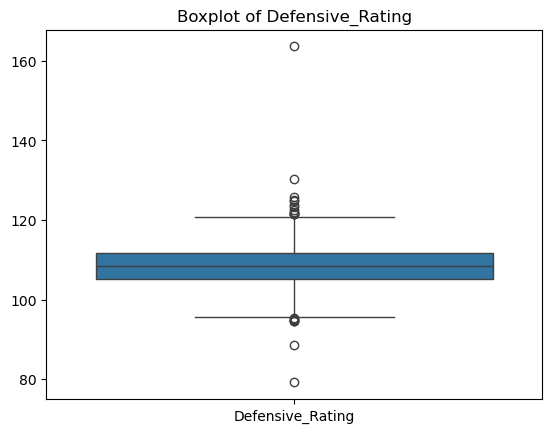

In [394]:
sns.boxplot(data=merged_df.loc[:, ['Defensive_Rating']])
plt.title("Boxplot of Defensive_Rating");

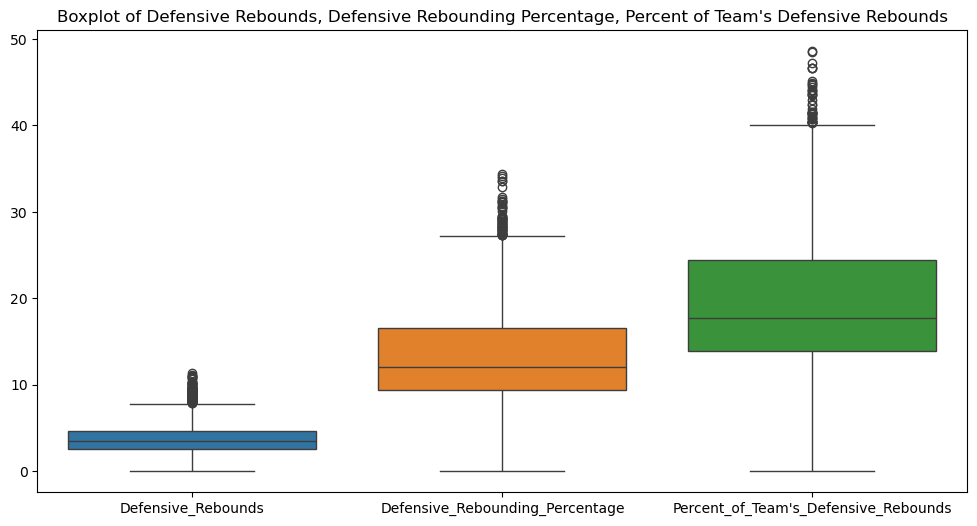

In [395]:
plt.figure(figsize=(12,6))
sns.boxplot(data=merged_df.loc[:, ['Defensive_Rebounds', 'Defensive_Rebounding_Percentage',
       "Percent_of_Team's_Defensive_Rebounds"]])
plt.title("Boxplot of Defensive Rebounds, Defensive Rebounding Percentage, Percent of Team's Defensive Rebounds");

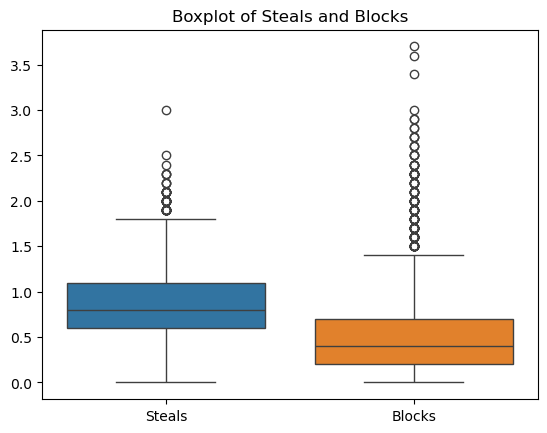

In [396]:
sns.boxplot(data=merged_df.loc[:, ['Steals', 'Blocks']])
plt.title("Boxplot of Steals and Blocks");

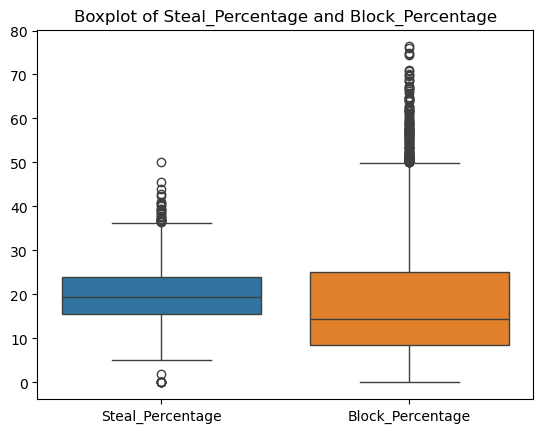

In [397]:
sns.boxplot(data=merged_df.loc[:, ['Steal_Percentage', 'Block_Percentage']])
plt.title("Boxplot of Steal_Percentage and Block_Percentage");

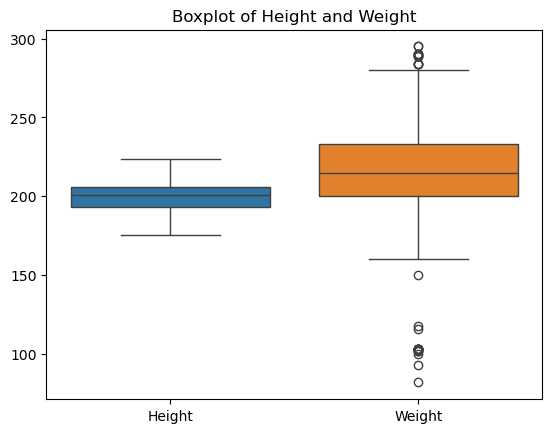

In [398]:
sns.boxplot(data=merged_df.loc[:, ['Height', 'Weight']])
plt.title("Boxplot of Height and Weight");

### Other Stats
We can see that there isn't any significant outlier in other stats.

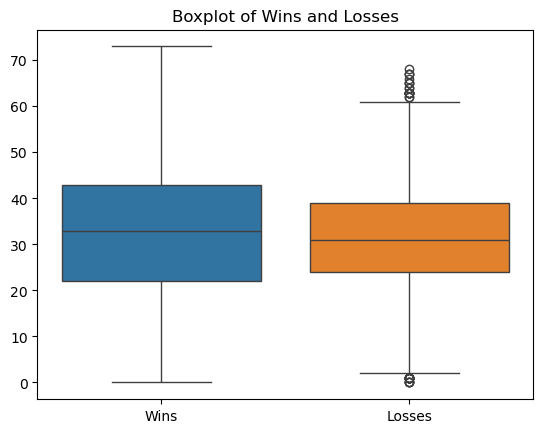

In [400]:
sns.boxplot(data=merged_df.loc[:, ['Wins', 'Losses']])
plt.title("Boxplot of Wins and Losses");

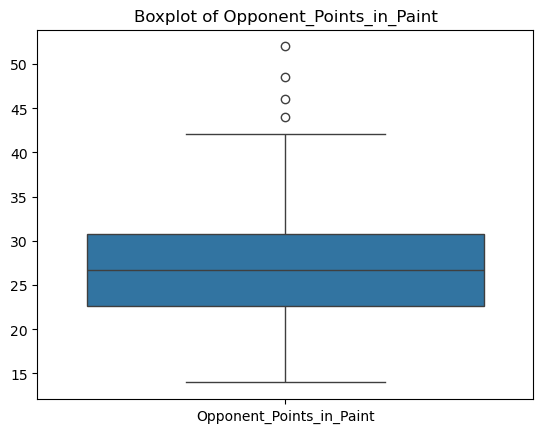

In [401]:
sns.boxplot(data=merged_df.loc[:, ['Opponent_Points_in_Paint']])
plt.title("Boxplot of Opponent_Points_in_Paint");

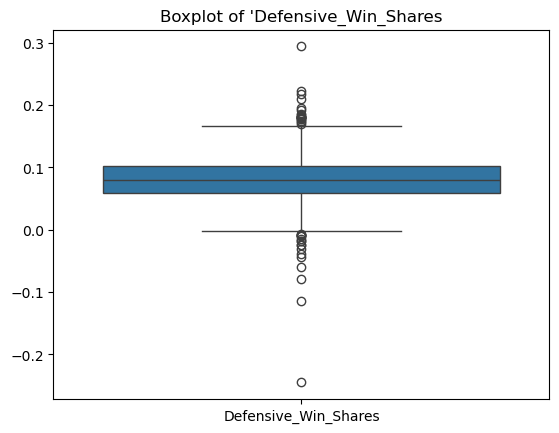

In [402]:
sns.boxplot(data=merged_df.loc[:, ['Defensive_Win_Shares']])
plt.title("Boxplot of 'Defensive_Win_Shares");

### Analysis on Steals & Blocks

Why do Steals and Blocks matter? 

### Core Defensive Metrics:

Steals and Blocks are foundational stats for evaluating a player’s defensive ability. DPOY winners are often among the league's leaders in these areas. Players who excel in disrupting the opposing team's offense through steals or protecting the rim with blocks often have a significant impact on their team's defense and, ultimately, their candidacy for DPOY.

### Measuring Defensive Impact:

Steals and blocks are tangible indicators of a player’s defensive activity and disruptive play. A player who can steal the ball or block shots frequently helps reduce scoring opportunities for the opponent, which is crucial for winning defensive honors.

In [404]:
df_dpoy = merged_df[merged_df['Nominee'] == 1]
df_non_dpoy = merged_df[merged_df['Nominee'] == 0]

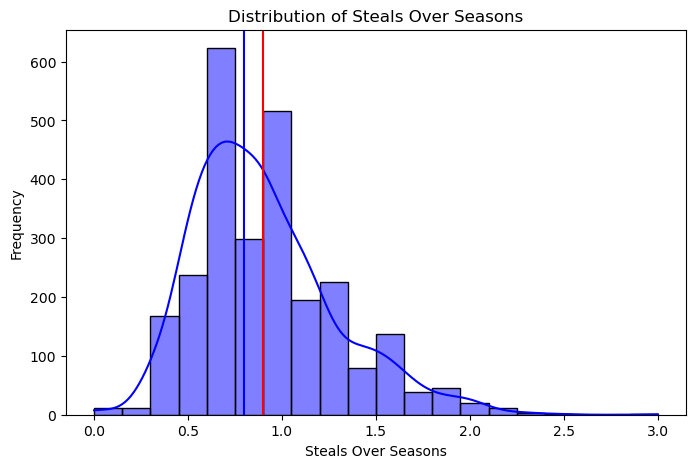

In [405]:
# Steals Distribution
plt.figure(figsize=(8, 5))
sns.histplot(merged_df["Steals"], bins=20, kde=True, color='blue', edgecolor='black')
plt.xlabel("Steals Over Seasons")
plt.ylabel("Frequency")
plt.title("Distribution of Steals Over Seasons")
plt.axvline(np.mean(merged_df["Steals"]), color='red'); 
plt.axvline(np.median(merged_df["Steals"]), color='blue');

The overall distribution of steals is right-skewed throughout 2014-2024 seasons.

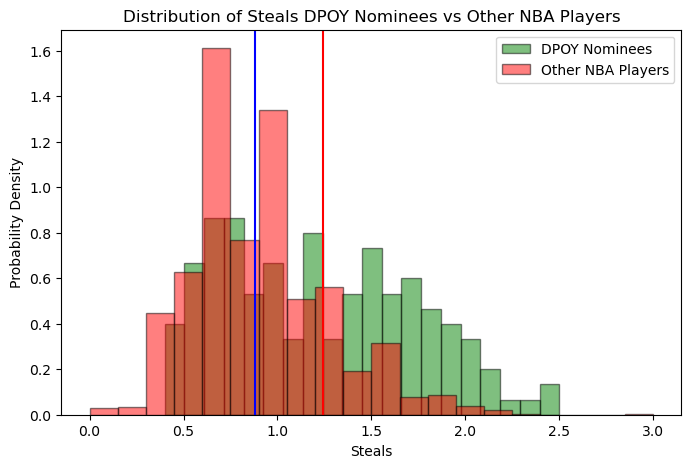

In [407]:
# Plot for DPOY nominees
plt.figure(figsize=(8, 5))
plt.hist(df_dpoy['Steals'], bins = 20, alpha=0.5, label='DPOY Nominees', color='green', density=True, edgecolor='black')

# Plot for non-DPOY nominees
plt.hist(df_non_dpoy['Steals'], bins = 20, alpha=0.5, label='Other NBA Players', color='red', density=True, edgecolor='black')

# Labels and title
plt.xlabel("Steals")
plt.ylabel("Probability Density")
plt.title("Distribution of Steals DPOY Nominees vs Other NBA Players")
plt.axvline(np.mean(df_dpoy['Steals']), color='red'); 
plt.axvline(np.mean(df_non_dpoy['Steals']), color='blue'); 

# Display the legend
plt.legend();

DPOY nominees have more steals than other NBA players on average. 

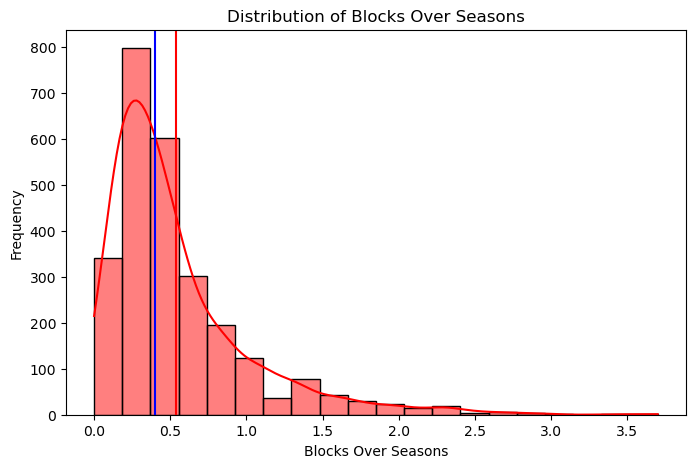

In [409]:
# Blocks Distribution
plt.figure(figsize=(8, 5))
sns.histplot(merged_df["Blocks"], bins=20, kde=True, color='red', edgecolor='black')
plt.xlabel("Blocks Over Seasons")
plt.ylabel("Frequency")
plt.title("Distribution of Blocks Over Seasons")
plt.axvline(np.mean(merged_df["Blocks"]), color='red'); 
plt.axvline(np.median(merged_df["Blocks"]), color='blue');

The overall distribution of blocks is right-skewed throughout 2014-2024 seasons.

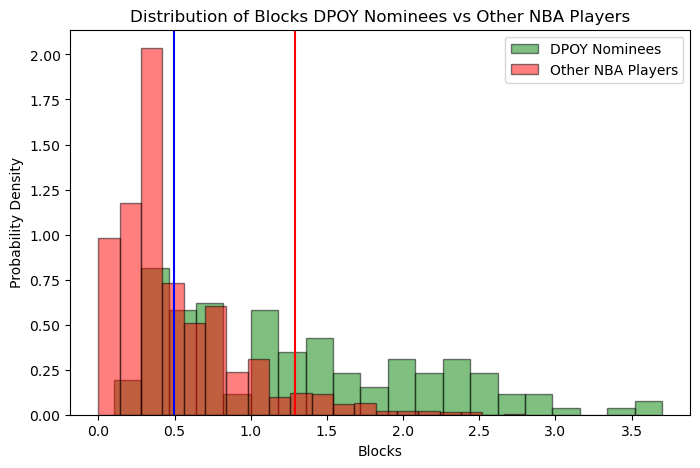

In [411]:
# Plot for DPOY nominees
plt.figure(figsize=(8, 5))
plt.hist(df_dpoy['Blocks'], bins = 20, alpha=0.5, label='DPOY Nominees', color='green', density=True, edgecolor='black')

# Plot for non-DPOY nominees
plt.hist(df_non_dpoy['Blocks'], bins = 20, alpha=0.5, label='Other NBA Players', color='red', density=True, edgecolor='black')

# Labels and title
plt.xlabel("Blocks")
plt.ylabel("Probability Density")
plt.title("Distribution of Blocks DPOY Nominees vs Other NBA Players")
plt.axvline(np.mean(df_dpoy['Blocks']), color='red'); 
plt.axvline(np.mean(df_non_dpoy['Blocks']), color='blue'); 

# Display the legend
plt.legend();

DPOY nominees have more blocks than other NBA players on average. 

The Distributions of the histograms show how steals and blocks are spread across the league. By identifying the top performers and the outliers, we can pinpoint players who are likely candidates for DPOY based on these stats.

We can see that generally a much smaller amount of players have an average around the 2.0 - 2.5 mark for both stats and these players would 'likely' be more consdiered as nominees, though steals and blocks are not the only factors as we will see more below. 

The frequency of high steals and blocks can highlight statistical thresholds that are associated with DPOY contenders. Players in the top percentiles of these metrics often end up being in the running for the award, and so these plots significantly helps us in terms of having predictive features for DPOY winners and nominees. 

### Analysis on Defensive Rating
Next let's take a look at Defensive Rating which is an important metric when determing how good at defense a NBA team is. Defensive Rating measures how many points a team allows per 100 possessions, with lower numbers indicating better defense. So let's see how the Defensive Rating of DPOYs nominees fair against the non-DPOY nominees.

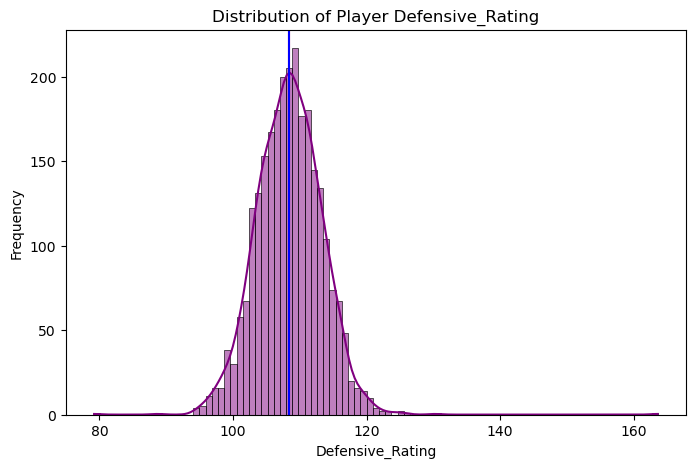

In [415]:
# Defensive Rating Distribution
plt.figure(figsize=(8, 5))
sns.histplot(merged_df["Defensive_Rating"], kde=True, color='purple')
plt.xlabel("Defensive_Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Defensive_Rating")
plt.axvline(np.mean(merged_df["Defensive_Rating"].dropna()), color='red'); 
plt.axvline(np.median(merged_df["Defensive_Rating"].dropna()), color='blue');

From the histogram above, we can see that the mean and median are nearly identical, indicating that the distribution of defensive rating is centered, symmetric, and approximately normal.

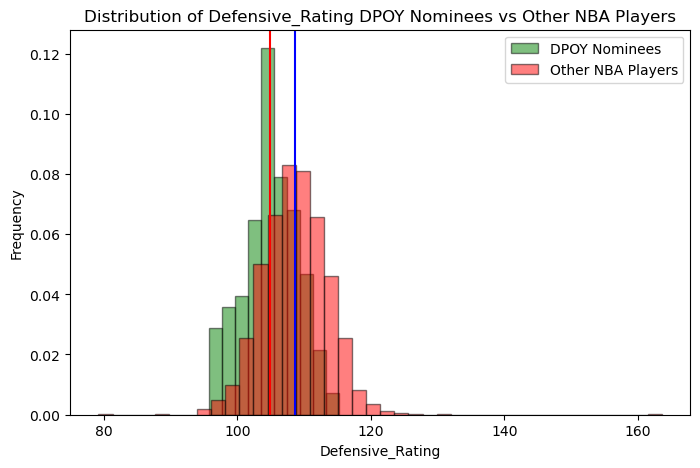

In [417]:
# Plot for DPOY nominees
plt.figure(figsize=(8, 5))
plt.hist(df_dpoy['Defensive_Rating'], alpha=0.5, label='DPOY Nominees', color='green', density=True, edgecolor='black')

# Plot for non-DPOY nominees
plt.hist(df_non_dpoy['Defensive_Rating'], bins = 40, alpha=0.5, label='Other NBA Players', color='red', density=True, edgecolor='black')

# Labels and title
plt.xlabel("Defensive_Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Defensive_Rating DPOY Nominees vs Other NBA Players")
plt.axvline(np.mean(df_dpoy['Defensive_Rating']), color='red'); 
plt.axvline(np.mean(df_non_dpoy['Defensive_Rating']), color='blue'); 

# Display the legend
plt.legend();

As seen in the graph, the distribution for DPOY nominees is shifted to the left of the distribution for the rest of the NBA. The average defensive rating for DPOYs is lower than that of other NBA players, with lower scores being better. This strongly suggests that Defensive Rating may play a key role in determining the DPOY.

### Analysis on Players Height and Weight

How does height and weight play into predicting DPOY?

Height and weight play a significant role in predicting the DPOY since they influence a player's defensive capability, rim protection, and ability to guard multiple positions. Taller players with longer wingspans excel at blocking shots and putting pressure on an opponents shot attempt, while heavier players can better handle physical matchups in the post.

To explore these factors, we will examine the height and weight distributions to illustrate their spread across the league. The frequency distributions of height and weight also help identify player trends, with certain ranges being more common for specific positions—for example, centers tend to be taller and heavier. Understanding these patterns provides deeper insight into how height and weight may influence a player's potential for winning DPOY.

We can identify the tallest players, some reaching up to 7 feet 4 inches (223.52 cm), as well as the heaviest players, both of which may help in predicting the DPOY.



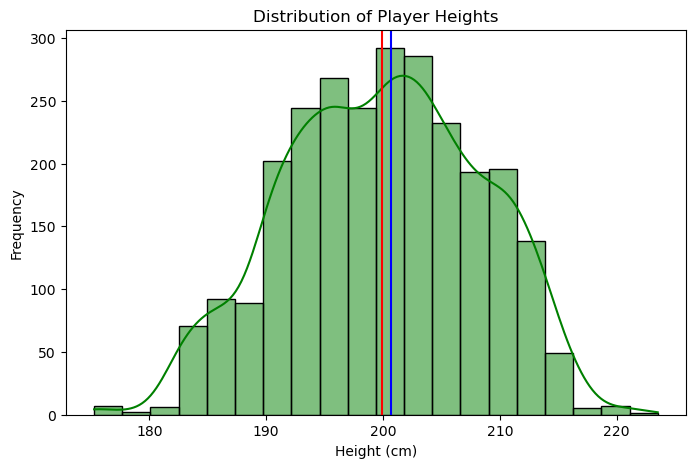

In [420]:
# Height Distribution
plt.figure(figsize=(8, 5))
sns.histplot(merged_df["Height"], bins=20, kde=True, color='green', edgecolor='black');
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.title("Distribution of Player Heights");
plt.axvline(np.mean(merged_df["Height"]), color='red'); 
plt.axvline(np.median(merged_df["Height"]), color='blue');

The distribution of height is a bit left-skewed.

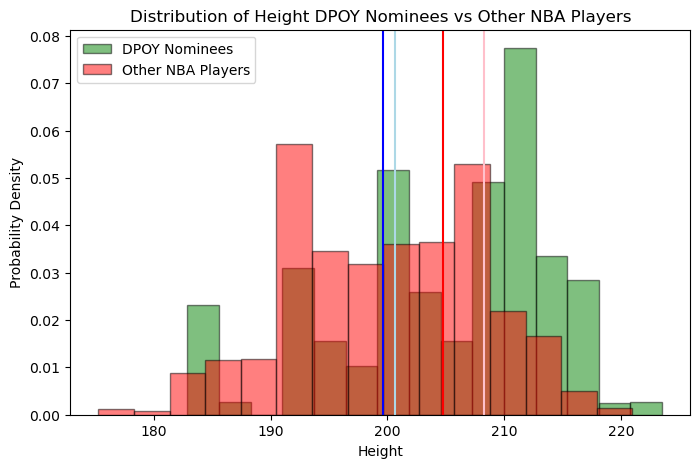

In [422]:
# Plot for DPOY nominees
plt.figure(figsize=(8, 5))
plt.hist(df_dpoy['Height'], bins = 15, alpha=0.5, label='DPOY Nominees', color='green', density=True, edgecolor='black')

# Plot for non-DPOY nominees
plt.hist(df_non_dpoy['Height'], bins = 15, alpha=0.5, label='Other NBA Players', color='red', density=True, edgecolor='black')

# Labels and title
plt.xlabel("Height")
plt.ylabel("Probability Density")
plt.title("Distribution of Height DPOY Nominees vs Other NBA Players")
plt.axvline(np.mean(df_dpoy['Height']), color='red'); 
plt.axvline(np.median(df_dpoy['Height']), color='pink'); 
plt.axvline(np.mean(df_non_dpoy['Height']), color='blue'); 
plt.axvline(np.median(df_non_dpoy['Height']), color='lightblue'); 

# Display the legend
plt.legend();

DPOY nominees are taller on average than the rest of the NBA.

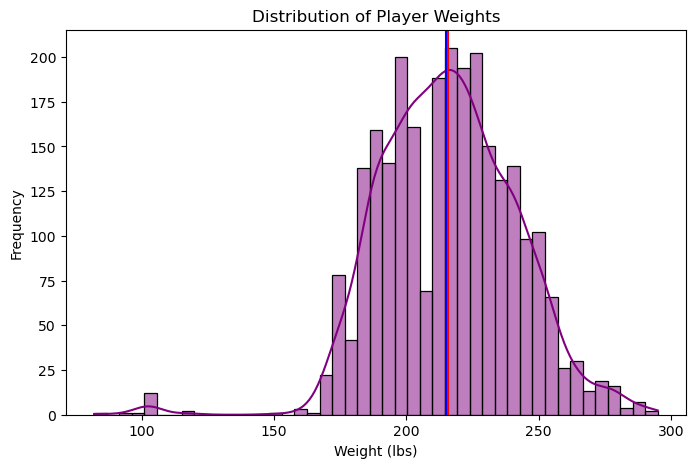

In [424]:
# Weight Distribution
plt.figure(figsize=(8, 5))
sns.histplot(merged_df["Weight"], kde=True, color='purple')
plt.xlabel("Weight (lbs)")
plt.ylabel("Frequency")
plt.title("Distribution of Player Weights")
plt.axvline(np.mean(merged_df["Weight"]), color='red'); 
plt.axvline(np.median(merged_df["Weight"]), color='blue');

The distribution of weight is approximately symmetric and centered.

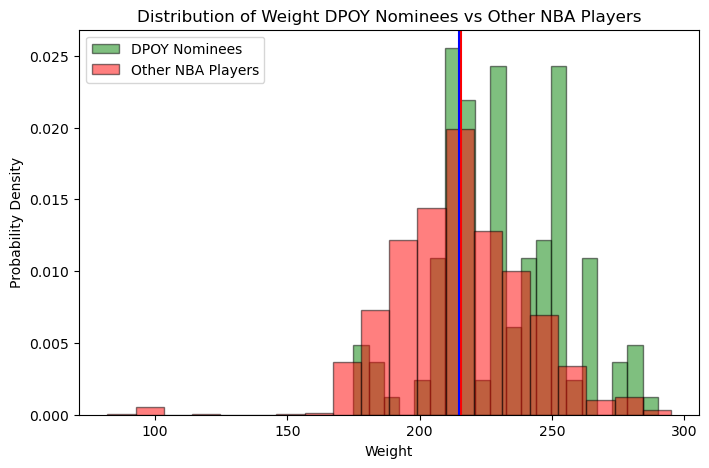

In [426]:
# Plot for DPOY nominees
plt.figure(figsize=(8, 5))
plt.hist(df_dpoy['Weight'], bins = 20, alpha=0.5, label='DPOY Nominees', color='green', density=True, edgecolor='black')

# Plot for non-DPOY nominees
plt.hist(df_non_dpoy['Weight'], bins = 20, alpha=0.5, label='Other NBA Players', color='red', density=True, edgecolor='black')

# Labels and title
plt.xlabel("Weight")
plt.ylabel("Probability Density")
plt.title("Distribution of Weight DPOY Nominees vs Other NBA Players")
plt.axvline(np.mean(merged_df["Weight"]), color='red'); 
plt.axvline(np.median(merged_df["Weight"]), color='blue');

# Display the legend
plt.legend();

Although the mean weights of DPOY nominees and NBA players are nearly identical, the weight distribution of DPOY nominees is shifted further to the right compared to that of the rest of the NBA.

As seen in the first histogram comparing the heights of DPOY nominees to other NBA players, DPOYs tend to be taller than the league average, with 50% significantly exceeding the average player's height. Similarly, the second histogram comparing weights shows that most DPOY nominees are heavier than the rest of the league. These findings suggest that physical advantages, such as height and weight, correlate with increased defensive activity and may be key factors in predicting the Defensive Player of the Year.

### Relationship Between Height and Blocks
The following scatter plot shows an increasing trend in the number of blocks a player has as their height increases, showing a positive nonlinear relationship between blocks and height.

In [430]:
from matplotlib.lines import Line2D

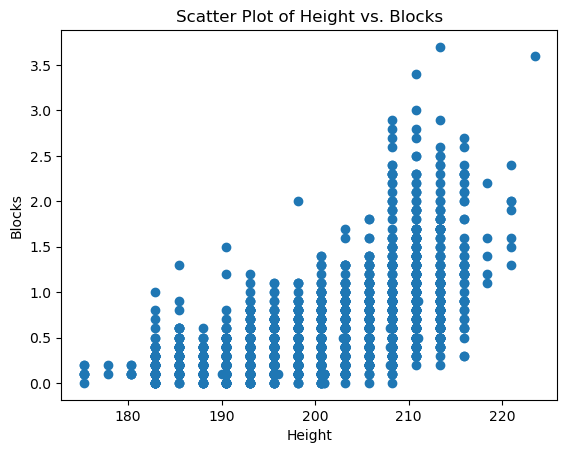

In [431]:
plt.scatter(merged_df[['Height', 'Blocks']].dropna()['Height'], merged_df[['Height', 'Blocks']].dropna()['Blocks'])
plt.xlabel("Height")
plt.ylabel("Blocks")
plt.title("Scatter Plot of Height vs. Blocks")
plt.show()

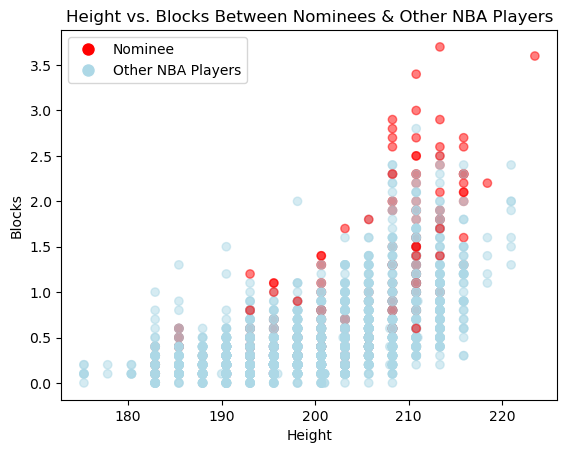

In [432]:
plt.scatter(
    merged_df[['Height', 'Blocks']].dropna()['Height'], 
    merged_df[['Height', 'Blocks']].dropna()['Blocks'], 
    c=['red' if c == True else 'lightblue' for c in merged_df['Nominee']], 
    alpha=0.5
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Nominee'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Other NBA Players')
]


plt.legend(handles=legend_handles)
plt.xlabel("Height")
plt.ylabel("Blocks")
plt.title("Height vs. Blocks Between Nominees & Other NBA Players");

Given the same height, DPOY nominees tend to have relatively more blocks than other NBA players.

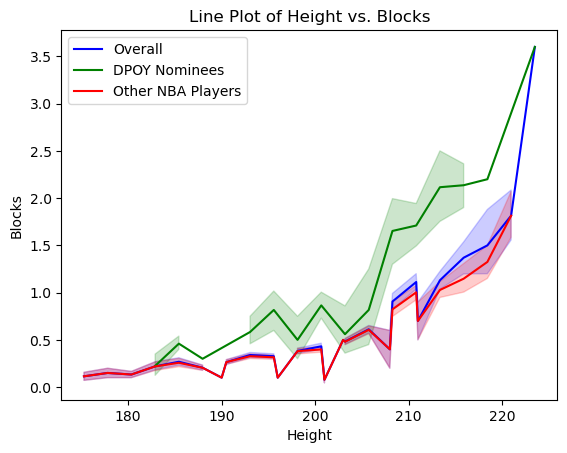

In [434]:
# Line plot for overall data
sns.lineplot(data=merged_df, x='Height', y='Blocks', label='Overall', color='blue')

# Line plot for DPOY nominees
sns.lineplot(data=df_dpoy, x='Height', y='Blocks', label='DPOY Nominees', color='green')

# Line plot for non-DPOY nominees
sns.lineplot(data=df_non_dpoy, x='Height', y='Blocks', label='Other NBA Players', color='red')

plt.xlabel("Height")
plt.ylabel("Blocks")
plt.title("Line Plot of Height vs. Blocks")
plt.legend();

The rest of the NBA follows a similar trend to the overall relationship between height and blocks, while DPOY nominees exhibit a consistently higher trend.

As seen from the analysis on blocks from above, a player's height heavily influences their ability to block shots, with taller players usually getting more blocks.

### Relationship Between Height and Defensive Rebounds
Again in this scatter plot we can see that as players get taller they grab more rebounds. Furthering out assumption and intuition that the increase in height allows for them to better suit defensive needs and collect defensive stats, however there are some outliers which can also be nominees for DPOY.

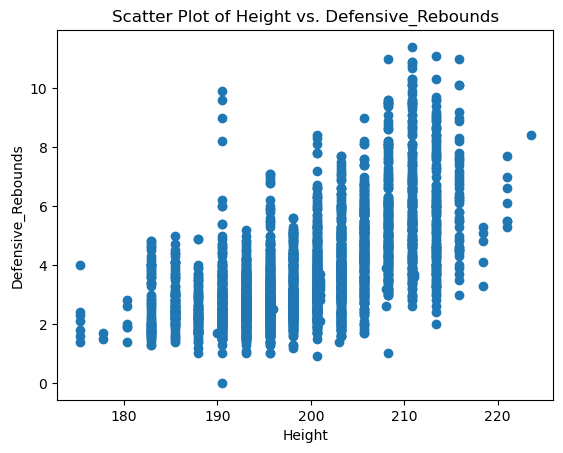

In [437]:
plt.scatter(merged_df[['Height', 'Defensive_Rebounds']].dropna()['Height'], merged_df[['Height', 'Defensive_Rebounds']].dropna()['Defensive_Rebounds'])
plt.xlabel("Height")
plt.ylabel("Defensive_Rebounds")
plt.title("Scatter Plot of Height vs. Defensive_Rebounds")
plt.show()

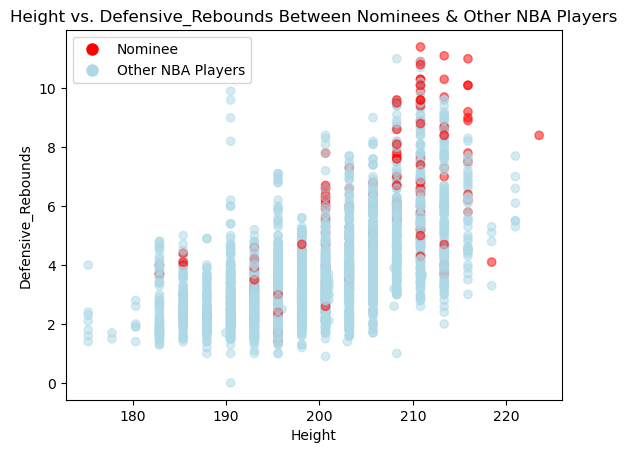

In [438]:
plt.scatter(
    merged_df[['Height', 'Defensive_Rebounds']].dropna()['Height'], 
    merged_df[['Height', 'Defensive_Rebounds']].dropna()['Defensive_Rebounds'], 
    c=['red' if c == True else 'lightblue' for c in merged_df['Nominee']], 
    alpha=0.5
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Nominee'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Other NBA Players')
]


plt.legend(handles=legend_handles)
plt.xlabel("Height")
plt.ylabel("Defensive_Rebounds")
plt.title("Height vs. Defensive_Rebounds Between Nominees & Other NBA Players");

Given the same height, DPOY nominees tend to have relatively more defensive rebounds than the rest of the league.

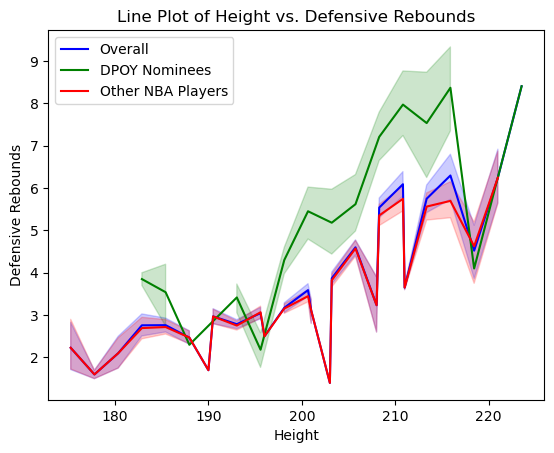

In [440]:
# Line plot for overall data
sns.lineplot(data=merged_df, x='Height', y='Defensive_Rebounds', label='Overall', color='blue')

# Line plot for DPOY nominees
sns.lineplot(data=df_dpoy, x='Height', y='Defensive_Rebounds', label='DPOY Nominees', color='green')

# Line plot for non-DPOY nominees
sns.lineplot(data=df_non_dpoy, x='Height', y='Defensive_Rebounds', label='Other NBA Players', color='red')

plt.xlabel("Height")
plt.ylabel("Defensive Rebounds")
plt.title("Line Plot of Height vs. Defensive Rebounds")
plt.legend();

NBA players follow a similar trend to the overall relationship between height and defensive rebounds, while DPOY nominees exhibit a consistently higher trend.

As seen in the line chart Height vs. Defensive Rebounds, the trend is not purely linear, displaying fluctuations along the line. This variation may be influenced by a player's role on their team—shorter teams may prioritize rebounding more, affecting individual statistics. Similarly, in the second graph, we observe a comparable trend, where an increase in height correlates with a rise in the average number of blocks.

From the scatter plots and line graphs above, the positive correlation between height and the increase in average blocks and defensive rebounds per season is clearly evident.

### Relationship Between Height and Steals
However when we look at another major defensive stat, steals, we can see that there is less of a positive trend in relation to height. Rather players around 220cm and below averaging more steals. These players being Small-Forwards and Guards. Thus is there different criteria for defensive player of the year based on height/position? As although taller players may have an advantage with blocking, there is no physical attribute that gives a great advantage for steals.

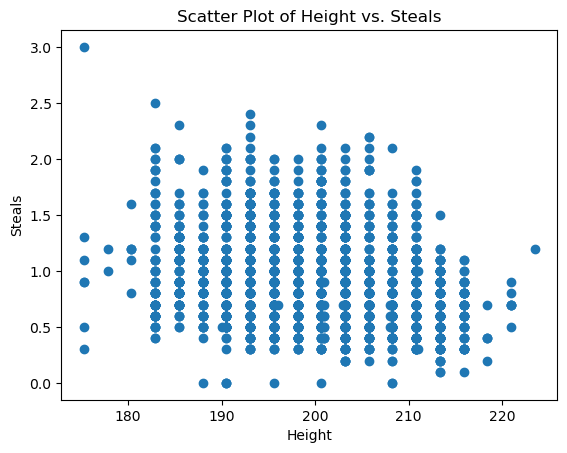

In [444]:
plt.scatter(merged_df[['Height', 'Steals']].dropna()['Height'], merged_df[['Height', 'Steals']].dropna()['Steals'])
plt.xlabel("Height")
plt.ylabel("Steals")
plt.title("Scatter Plot of Height vs. Steals")
plt.show()

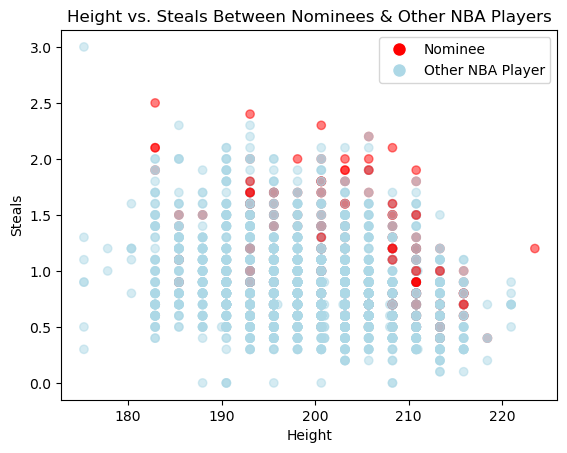

In [445]:
plt.scatter(
    merged_df[['Height', 'Steals']].dropna()['Height'], 
    merged_df[['Height', 'Steals']].dropna()['Steals'], 
    c=['red' if c == True else 'lightblue' for c in merged_df['Nominee']], 
    alpha=0.5
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Nominee'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Other NBA Player')
]


plt.legend(handles=legend_handles)
plt.xlabel("Height")
plt.ylabel("Steals")
plt.title("Height vs. Steals Between Nominees & Other NBA Players");

The scatter plot above shows a negative nonlinear relationship between height and steals. At the same height, DPOY nominees tend to record more steals than other players.

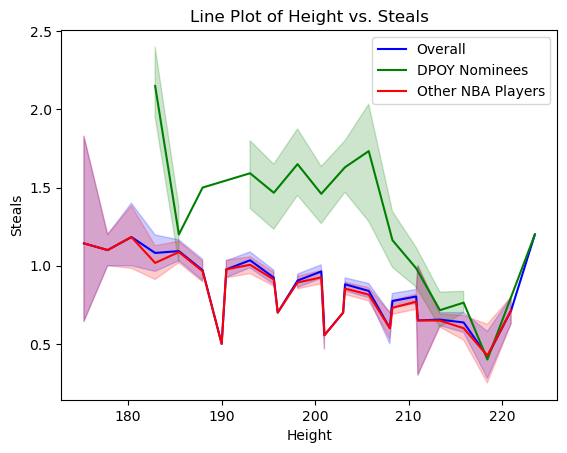

In [447]:
# Line plot for overall data
sns.lineplot(data=merged_df, x='Height', y='Steals', label='Overall', color='blue')

# Line plot for DPOY nominees
sns.lineplot(data=df_dpoy, x='Height', y='Steals', label='DPOY Nominees', color='green')

# Line plot for non-DPOY nominees
sns.lineplot(data=df_non_dpoy, x='Height', y='Steals', label='Other NBA Players', color='red')

plt.xlabel("Height")
plt.ylabel("Steals")
plt.title("Line Plot of Height vs. Steals")
plt.legend();

### Analysis on Team Standing
In this section, we will explore the relationship between team standings and DPOY nominees. Our analysis will focus on NBA players from the 2014-2024 seasons, examining how the success of a team's roster, correlates with the likelihood of a player being nominated for DPOY. By grouping the data by team, we will calculate the nomination rate—the proportion of players from each team who have received a DPOY nomination during this period.

In doing so, we aim to uncover trends and patterns in the relationship between team performance and individual defensive accolades. For example, teams with higher standings in the regular season may be more likely to produce DPOY candidates, as players on successful teams are often given more visibility and recognition. Conversely, we might also find that certain teams, even with lower overall standings, could still have standout defensive players who are nominated for DPOY due to their individual contributions.

To perform this analysis, we’ll calculate the rate of DPOY nominees for each team. We’ll do this by dividing the number of DPOY nominations a team’s players have gotten by the total number of players on that team over the 2014-2024 period. This will give us a sense of how likely a team is to produce a player known for their defensive skills. On top of that, we’ll visualize the data to see if there’s any clear connection between a team’s overall success (team standings) and how often they produce DPOY nominees.

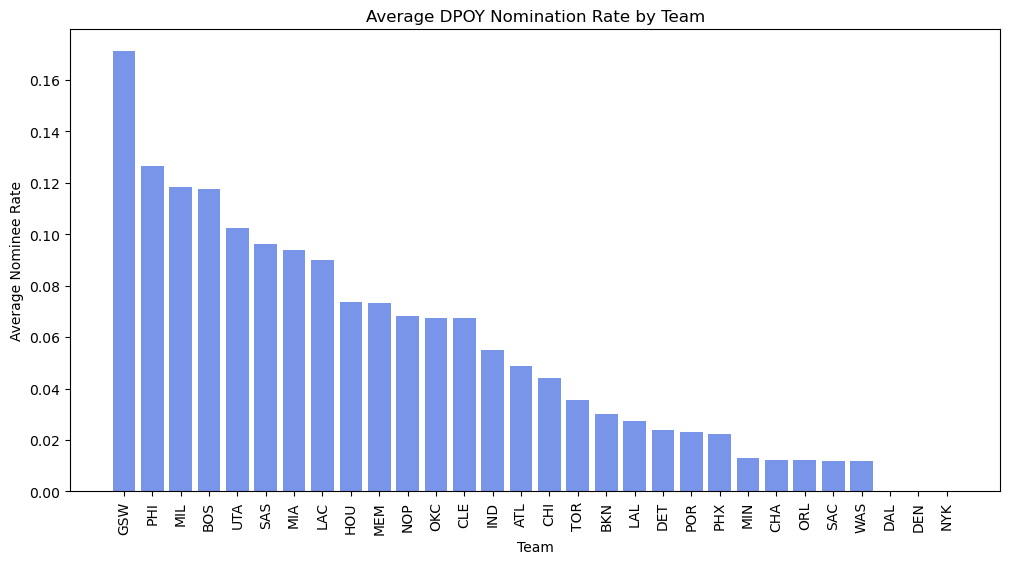

In [449]:
# Compute the mean nomination rate per team
team_nominee_rates = merged_df.groupby('Team')['Nominee'].mean()

# Sort values for better visualization
team_nominee_rates = team_nominee_rates.sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(team_nominee_rates.index, team_nominee_rates.values, color='royalblue', alpha=0.7)

# Labels and title
plt.xlabel("Team")
plt.ylabel("Average Nominee Rate")
plt.title("Average DPOY Nomination Rate by Team")
plt.xticks(rotation=90)  # Rotate team names for readability

# Show plot
plt.show()

From the bar graph above, we can see that the Golden State Warriors (GSW), an NBA team based in San Francisco, California, have the highest DPOY nominee rate from 2014-2024, with around 17%. GSW stands out with a significantly higher rate of producing DPOY nominees compared to other teams. This could be attributed to their emphasis on strong defensive systems and versatile defenders like Draymond Green, who has been a key DPOY contender multiple times during this period. The Warriors' success in recent years, including several championships, likely also plays a role in elevating their defensive players' visibility and recognition.

Next is the Philadelphia 76ers (PHI), with a DPOY nominee rate of 12%. The 76ers have produced standout defensive players such as Joel Embiid and Ben Simmons, who have received considerable attention for their defensive prowess. Their focus on building a solid defense under coach Brett Brown (and later Doc Rivers) has contributed to their strong showing in this area.

The Milwaukee Bucks and Boston Celtics follow closely with a DPOY nominee rate of about 11.8%. The Bucks, with Giannis Antetokounmpo and their elite defensive schemes, and the Celtics, with players like Marcus Smart (the 2022 DPOY), have consistently been strong on defense. Both teams have made deep playoff runs during this period, which has brought their defensive players into the spotlight.

Finally, the Utah Jazz (UTA), based in Salt Lake City, Utah, come in fifth with a nominee rate of around 10%. The Jazz have been known for their strong defensive identity, led by Rudy Gobert, who won multiple DPOY awards during this period. Although their team success hasn't always matched the level of teams like the Warriors or Celtics, Gobert’s consistent excellence on defense has made the Jazz a notable team in the DPOY conversation.

These rankings reflect not just individual talent but also team success, as teams with higher overall standings and playoff contention tend to give their defensive players more recognition. 

# Predictive Classification Modeling

Printing the past winners from the last 10 seasons as reference: 

In [453]:
# Filter the DataFrame for players who are winners
winners = merged_df[merged_df['Winner'] == 1]

# Print the winners
print(winners[['Player', 'Team', 'Winner', 'Defensive_Win_Shares']])  

                     Player Team  Winner  Defensive_Win_Shares
4               Joakim Noah  CHI    True                 0.163
232           Kawhi Leonard  SAS    True                 0.148
469           Kawhi Leonard  SAS    True                 0.185
707          Draymond Green  GSW    True                 0.158
942             Rudy Gobert  UTA    True                 0.180
1200            Rudy Gobert  UTA    True                 0.141
1444  Giannis Antetokounmpo  MIL    True                 0.195
1691            Rudy Gobert  UTA    True                 0.181
1964           Marcus Smart  BOS    True                 0.145
2232      Jaren Jackson Jr.  MEM    True                 0.137
2476            Rudy Gobert  MIN    True                 0.164


## SVM Model Analysis
Our first model of choice is a Support Vector Machine (SVM) Model. We will first import the necessary files.

In [455]:
# Importing files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")


df = merged_df.copy()

# Define the feature columns (same as before)
features = [
    "Wins", "Losses", "Defensive_Rating", "Defensive_Rebounds", "Defensive_Rebounding_Percentage",
    "Steals", "Steal_Percentage", "Blocks", "Block_Percentage",
    "Opponent_Points_in_Paint", "Defensive_Win_Shares", "Height", "Weight"
]
target = "Winner" 

# Split data based on Year (Training on data before 2023-2024 season, testing on 2023-2024 season data)
train_data = df[df["Year"] < 2024]
test_data = df[df["Year"] == 2024]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM model
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Model accuracy and evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print results
print(f"Model Accuracy: {accuracy:.2f}")
print(report)

Model Accuracy: 0.99
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       147
        True       0.00      0.00      0.00         1

    accuracy                           0.99       148
   macro avg       0.50      0.50      0.50       148
weighted avg       0.99      0.99      0.99       148



Now, we determine the most important factors in the model to determine the DPOY.

Feature Importances (SVM Coefficients):
                            Feature  Importance
10             Defensive_Win_Shares    1.316317
4   Defensive_Rebounding_Percentage    0.792420
5                            Steals    0.619027
2                  Defensive_Rating    0.594953
9          Opponent_Points_in_Paint    0.544554
7                            Blocks    0.527978
3                Defensive_Rebounds    0.491690
0                              Wins    0.309892
6                  Steal_Percentage    0.162682
12                           Weight    0.116334
8                  Block_Percentage    0.083271
11                           Height    0.026755
1                            Losses    0.025768


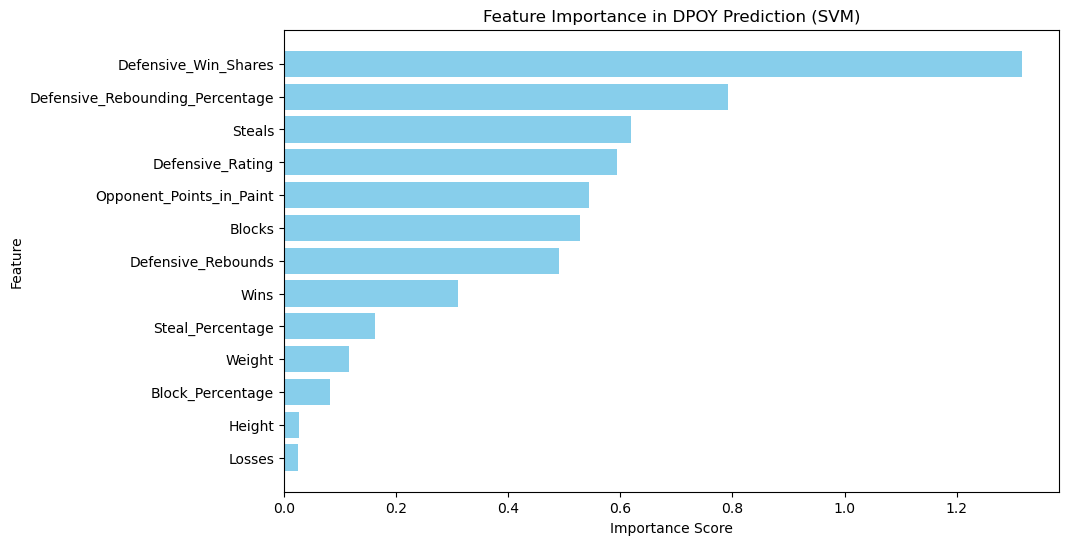

In [457]:
# Extract feature importance from SVM model (only works for linear kernel)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(svm_model.coef_[0])
}).sort_values(by="Importance", ascending=False)

# Display feature importances
print("Feature Importances (SVM Coefficients):")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance in DPOY Prediction (SVM)")
plt.gca().invert_yaxis()
plt.show()

As we can see, Defensive Win Shares (1.32) has the highest Importance Score, with Defensive Rebounding Percentage (0.79), Steals (0.62), and Defensive Rebounds (0.59) trailed behind.

Finally, we predict and list the top candidates for the next Defensive Player of the Year.

In [459]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Training features:", X_train.columns)
print("Testing features:", X_test.columns)

missing_cols = set(X_train.columns) - set(X_test.columns)
extra_cols = set(X_test.columns) - set(X_train.columns)

print("Missing columns in X_test:", missing_cols)
print("Unexpected columns in X_test:", extra_cols)


X_train shape: (2476, 13)
X_test shape: (148, 13)
Training features: Index(['Wins', 'Losses', 'Defensive_Rating', 'Defensive_Rebounds',
       'Defensive_Rebounding_Percentage', 'Steals', 'Steal_Percentage',
       'Blocks', 'Block_Percentage', 'Opponent_Points_in_Paint',
       'Defensive_Win_Shares', 'Height', 'Weight'],
      dtype='object')
Testing features: Index(['Wins', 'Losses', 'Defensive_Rating', 'Defensive_Rebounds',
       'Defensive_Rebounding_Percentage', 'Steals', 'Steal_Percentage',
       'Blocks', 'Block_Percentage', 'Opponent_Points_in_Paint',
       'Defensive_Win_Shares', 'Height', 'Weight'],
      dtype='object')
Missing columns in X_test: set()
Unexpected columns in X_test: set()


In [460]:
# Get probabilities of being a DPOY winner for 2024
future_data = df[df["Year"] == 2024].copy() 

# Extract and scale the features used in training
X_future = future_data[features]
X_future_scaled = scaler.transform(X_future)

# Predict DPOY probabilities
future_data["DPOY_Probability"] = svm_model.predict_proba(X_future_scaled)[:, 1]
top_candidates = future_data[["Player", "Team", "DPOY_Probability"]].sort_values(by="DPOY_Probability", ascending=False)
print("Top Predicted DPOY Candidates for 2024:")
print(top_candidates.head(10))  # Show top 10 candidates

Top Predicted DPOY Candidates for 2024:
                       Player Team  DPOY_Probability
2513        Victor Wembanyama  SAS          0.261975
2476              Rudy Gobert  MIN          0.125696
2480  Shai Gilgeous-Alexander  OKC          0.085021
2485             Nikola Jokić  DEN          0.029086
2490            Chet Holmgren  OKC          0.026884
2530             Jusuf Nurkić  PHX          0.024239
2529       Isaiah Hartenstein  NYK          0.021903
2479              Bam Adebayo  MIA          0.016850
2509              Alex Caruso  CHI          0.016302
2527            Anthony Davis  LAL          0.015037


## Logistic Regression Model Analysis
Our second model of choice is the logisitic regression model. We first need to import the necessary files:

In [462]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


df = merged_df.copy()

# Define the features and target variable
features = ['Wins', 'Defensive_Rating', 'Defensive_Rebounds', 'Defensive_Rebounding_Percentage', 
            "Percent_of_Team's_Defensive_Rebounds", 'Steals', 'Steal_Percentage', 
            'Blocks', 'Block_Percentage', 'Height', 'Weight', 'Defensive_Win_Shares', 'Year', 'Nominee', 'Winner']  

X = df[features].copy()

# Define target variable (binary: Top 5% Defensive Win Shares)
y = df["Defensive_Win_Shares"] > df["Defensive_Win_Shares"].quantile(0.95)  

# Split the data based on years (Train on all years except 2023, Test on 2023)
X_train = X[X["Year"] != 2024]  
y_train = y[X["Year"] != 2024]
X_test = X[X["Year"] == 2024]  
y_test = y[X["Year"] == 2024]

# Drop the 'Year' column from X after splitting (not needed for modeling)
X_train = X_train.drop(columns=["Year"])
X_test = X_test.drop(columns=["Year"])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=["Nominee", "Winner"])) 
X_test_scaled = scaler.transform(X_test.drop(columns=["Nominee", "Winner"])) 

# Train Logistic Regression Model
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)


print("=== Logistic Regression Results (Nominees) ===")
nominee_mask = X_test["Nominee"] == 1  
print(classification_report(y_test[nominee_mask], y_pred_log[nominee_mask]))
print(confusion_matrix(y_test[nominee_mask], y_pred_log[nominee_mask]))



=== Logistic Regression Results (Nominees) ===
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        10
        True       1.00      1.00      1.00         3

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

[[10  0]
 [ 0  3]]


We can see that the logistic model successfully denoted the right nominees, while also finding the right winner using the top 5% percentile of defensive win shares

In [464]:
print("\n=== Logistic Regression Results (Winners) ===")
winner_mask = X_test["Winner"] == 1  
print(classification_report(y_test[winner_mask], y_pred_log[winner_mask]))
print(confusion_matrix(y_test[winner_mask], y_pred_log[winner_mask]))


=== Logistic Regression Results (Winners) ===
              precision    recall  f1-score   support

        True       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1

[[1]]


Below are the nominees that our model predicted

In [466]:
# Get the model's predictions for nominees (where y_pred_log == 1 means nominee)
predicted_nominees_log = X_test[y_pred_log == 1]  # Getting the rows where the model predicted nominee
predicted_nominees_log = merged_df.loc[predicted_nominees_log.index, ['Player', 'Team']]  # Retrieving the Player and Team columns

print("Predicted Nominees (Logistic Regression):")
print(predicted_nominees_log)


Predicted Nominees (Logistic Regression):
                       Player Team
2476              Rudy Gobert  MIN
2477          Anthony Edwards  MIN
2478             Franz Wagner  ORL
2479              Bam Adebayo  MIA
2480  Shai Gilgeous-Alexander  OKC
2481             Jayson Tatum  BOS
2482           Jalen Williams  OKC


## Decision Tree Model Analysis

Our third choice of model is a Decision Tree. We first must import the necessary files, determine our predicting features, and make a trained decision model:

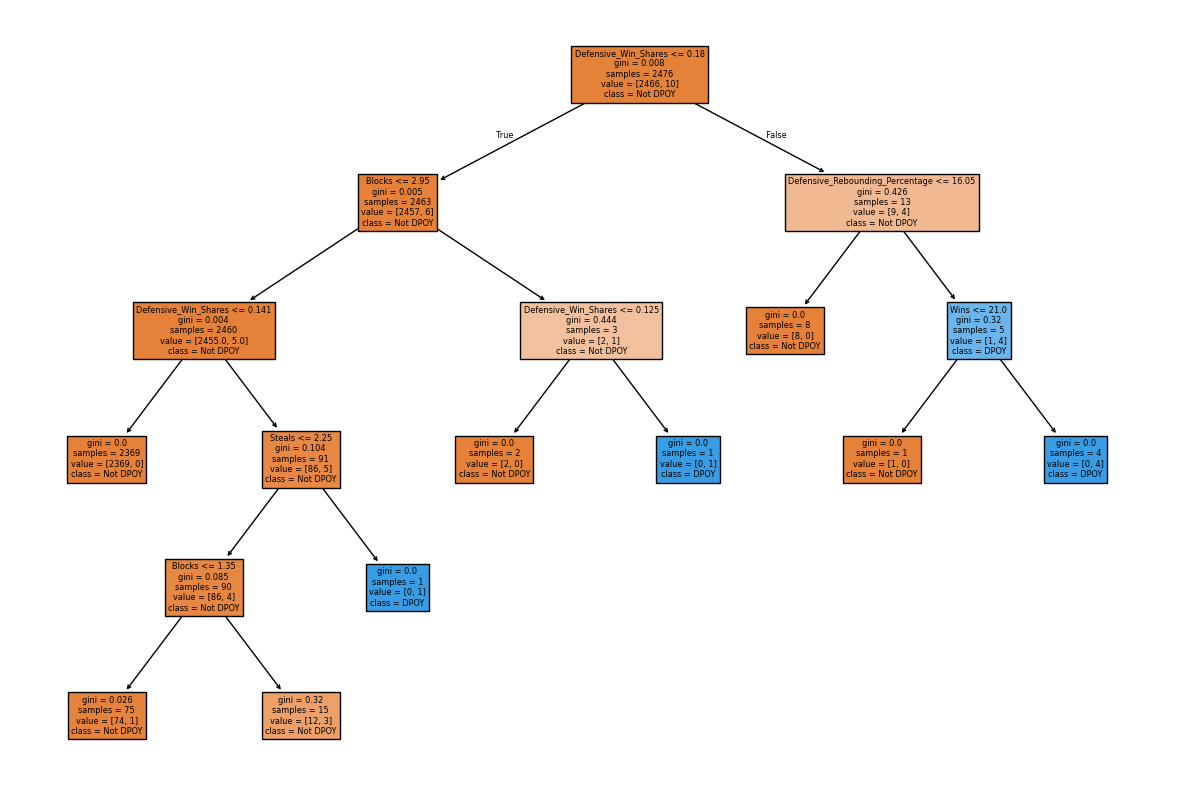

Model Accuracy: 0.99
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       147
        True       0.00      0.00      0.00         1

    accuracy                           0.99       148
   macro avg       0.50      0.50      0.50       148
weighted avg       0.99      0.99      0.99       148



In [468]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Define feature columns
features = [
    "Wins", "Losses", "Defensive_Rating", "Defensive_Rebounds", "Defensive_Rebounding_Percentage", "Steals", "Steal_Percentage",
    "Blocks", "Block_Percentage","Opponent_Points_in_Paint", "Defensive_Win_Shares", "Height", "Weight"
]
target = "Winner"

# Split data based on Year (Training on data before 2023-2024 season, testing on 2023-2024 season data)
train_data = df[df["Year"] < 2024]
test_data = df[df["Year"] == 2024]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# Train decision tree model
model = DecisionTreeClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

# Make prediction
y_pred = model.predict(X_test)

# Model accuracy and evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Display decision tree
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=features, class_names=["Not DPOY", "DPOY"], filled=True)
plt.show()

# Sccuracy and classification report
print(f"Model Accuracy: {accuracy:.2f}")
print(report)


Now, we determine which features are the most important in determining the Defensive Player of the Year.

Feature Importances:
                            Feature  Importance
10             Defensive_Win_Shares    0.325003
4   Defensive_Rebounding_Percentage    0.299596
5                            Steals    0.137389
0                              Wins    0.121711
7                            Blocks    0.116300
3                Defensive_Rebounds    0.000000
2                  Defensive_Rating    0.000000
1                            Losses    0.000000
6                  Steal_Percentage    0.000000
8                  Block_Percentage    0.000000
9          Opponent_Points_in_Paint    0.000000
11                           Height    0.000000
12                           Weight    0.000000


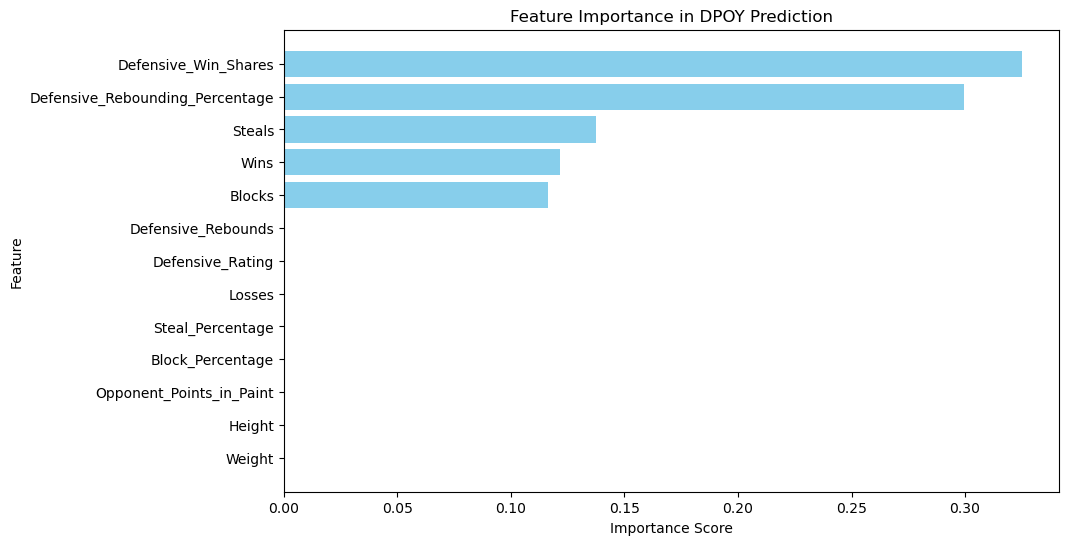

In [470]:
# Get feature importances
feature_importances = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Display feature importances
print("Feature Importances:")
print(feature_importances)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances["Feature"], feature_importances["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance in DPOY Prediction")
plt.gca().invert_yaxis()
plt.show()


As we can see, Defensive Win Shares and Defensive Revbounding Percentage happened to be the most important factors for determining the Defensive Player of the Year. Steals, Wins, Blocks, and Defensive Rating also had an impact, with other factors not being significant in determining in this model.

Now, we move to predicting the 2023-2024 DPOY based on the trained model:

In [473]:
# Get probabilities of being a DPOY winner
test_data = test_data.copy()
test_data["DPOY_Probability"] = model.predict_proba(X_test)[:, 1]

# Display top candidates
top_candidates = test_data[["Player", "Team", "DPOY_Probability"]].sort_values(by="DPOY_Probability", ascending=False)
print("Top DPOY Candidates for 2023-2024:")
print(top_candidates.head(5))


Top DPOY Candidates for 2023-2024:
                       Player Team  DPOY_Probability
2476              Rudy Gobert  MIN          0.200000
2477          Anthony Edwards  MIN          0.013333
2478             Franz Wagner  ORL          0.013333
2479              Bam Adebayo  MIA          0.000000
2480  Shai Gilgeous-Alexander  OKC          0.000000


This results in Rudy Gobert receiving the highest chance (20% probability to win), followed by a tie between Anthony Edwards and Franz Wagner (1.33% probability to win) Who all significantly helped their respective teams reach successes with their defensive contributions.

# Ethics & Privacy

We must address several key ethical considerations. First, while the data we are using is publicly available, we need to ensure that we comply with the terms of use for sources like NBA.com and Basketball Reference, respecting intellectual property and privacy. We also recognize potential biases in the dataset, especially when it comes to the representation of players from more successful or marketable teams who may attract more media attention, which could unfairly influence their DPOY nominations. To address this, we will conduct exploratory data analysis to identify any imbalances and actively work to mitigate these biases during our analysis. Moreover, we will maintain transparency throughout the process by clearly stating that our predictions are based on historical data and addressing any limitations or biases found in our analysis.

# Discusison and Conclusion


Looking back at some prior work that was done similarly to what we wanted to do, statistical modeling like ours was used to make predictions on the 2024-2025 MVP winners and candidates but they didn't cover the DPOY winner which we constructed some models to predict past winners and candidates. We tested out two different classification models, being the Decision Tree Model and the Logistic Regression Model. 

To begin, we orginally thought wingspan was going to be a significant factor in participating as one of our features in our modeling, however, we couldn't find data on wingspans for each player in the dataset other than from players during the season of 2024 so we scratched the idea. On the other hand though, we were able to acquire some important data needed to make DPOY predictions, in which we performed some EDA (Exploratory Data Analysis) related to these stats and features we extracted. After conducting some analysis on the data we found, we realized that a couple columns weren't really useful for the type of prediction we were going for. For example, the defensive rebounding percentage of a player is very important when they are considered for the award, but we also had a data column regarding the player's percentage of defensive rebounds in terms of the TEAM, which we felt was a little unecessary to include due to the award favoring a player's individual performance rather than relative to the team. Thus this was one feature we didn't consider in the modeling. 

Now, getting to the prediction analysis: To re-iterate, we tested two different classification models, being the Logistic Regression model and the Decision tree. We first assumed that the Decision Tree would perform better due to the high amount of features being considered in the analysis, however, it struggled to keep up with predicting the correct nominees for the year. Though, it was successful in finding the correct winner. Logistic Regression on the other hand also predicted the correct winner while also finding most of the nominees/candidates of the 2024 season. Under the hood, we also ran tests on years prior to the 2023-2024 season, in which the training data reduced by every year since we lose an entire season's data, and naturally, both models began to perform worse and worse due to less data being given. Below, we give a short reason on why Logistic Regression performed better than the Decision Tree. 

Logistic Regression performed better than the Decision Tree predicting nominees because it generalizes well to unseen data by finding a clear decision boundary. Since it's a linear model, it avoids overfitting, which is a common issue with Decision Trees that can become too complex and overly tailored to the training data. Decision Trees in general can sometimes get caught up in noise and make overly specific splits that don’t hold up well when tested on new seasons. Logistic Regression, on the other hand, assigns probabilities to predictions, making it more stable and reliable for classification tasks like this, where clear patterns in defensive stats matter more than intricate, tree-like decision-making. Additionally, while Logistic Regression and the Decision Tree predictions did turn out to be correct, the SVM modeled a more realistic scenario between the candidates: there were two top contenders, with then less likely choices who were still valuable defensive contributors for their team. The top two were between Victor Wembanyama (predicted first in the model, but finished second in voting), and Rudy Gobert (predicted second in the model, but won the DPOY Award), which was a highly debated topic at the time of the decision. That being said, the SVM may not have predicted correctly, but was certainly realistic in determining the top contenders for the award.

All-in-all, we were able to answer our research question properly, in which we successfully used Machine Learning methods by the use of prediction models to predict the winners and nearly got all the nominees/candidates correct for the 2023-2024 NBA season. The reason for the candidates not being perfectly outlooked by our models could be due to voting bias that the NBA has in which our models are only statistical analysis to make a prediction and doesn't factor in human opinion (naturally of course). Looking to the future, we would like to reconnect with one another once the 2024-2025 NBA season ends to test our models just prior to the actual results by the NBA to see if a good accuracy is achieved on an unseen data portion this time, in which we have high hopes for.

# Team Contributions

- Andy Nguyen: Responsible for generating research question, conducting exploratory data analysis (EDA) on past winners, and wrote prior work section.

- Tim Mao: Focused on predictive modeling, EDA, background research, and drafting the introduction.

- Shawn Malal: Led the data collection for NBA players from the past 11 years, worked on predictive modeling, contributed to background research, and co-authored the introduction and conclusion .

- Luca Schenck: Assisted with generating research questions, contributed to the development of the predictive model, wrote the abstract, contributed to conclusion.

- An-Chi Lu: Responsible for the ethics section, conducting EDA, organizing the notebook structure, and collecting data on nominees.
